# TODO LIST
## 1. INDEKSY DO SPRADZENIA, BIBLIOTEKI + REQUIREMENTS.TXT

In [117]:
from typing import Union

import matplotlib.pyplot as plt
import numpy as np
from keras.datasets import mnist
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from tqdm import tqdm

Loads the MNIST dataset.  This is a dataset of 60,000 28x28 grayscale images of the 10 digits, along with a test set of 10,000 images. More info can be found at the [MNIST homepage](http://yann.lecun.com/exdb/mnist/).

Args: path: path where to cache the dataset locally (relative to `~/.keras/datasets`).

Returns: Tuple of NumPy arrays: `(x_train, y_train), (x_test, y_test)`.

**`x_train`**: `uint8` NumPy array of grayscale image data with shapes `(60000, 28, 28)`, containing the training data. Pixel values range from 0 to 255.

**`y_train`**: `uint8` NumPy array of digit labels (integers in range 0-9) with shape `(60000,)` for the training data.

**`x_test`**: `uint8` NumPy array of grayscale image data with shapes `(10000, 28, 28)`, containing the test data. Pixel values range from 0 to 255.

**`y_test`**: `uint8` NumPy array of digit labels (integers in range 0-9) with shape `(10000,)` for the test data.  

In [118]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [119]:
# Normalization of data
x_train = x_train.astype(np.float32) / 255.0
x_test = x_test.astype(np.float32) / 255.0

In [120]:
input_index = 0  # Index of an input
x_train[input_index]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

Label: 3


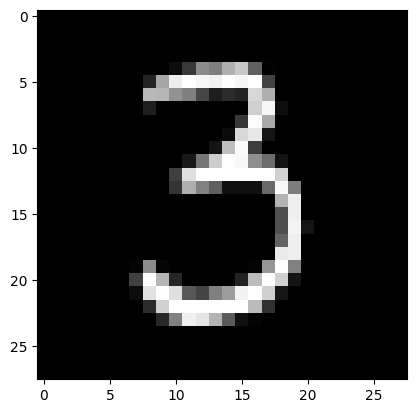

In [126]:
input_index = 50

# Print label and show image
y_target = y_train[input_index]
print("Label:", y_target)
plt.imshow(x_train[input_index], cmap="gray")
plt.show()

In [124]:
input_size = x_train.shape[1] * x_train.shape[2]
output_size = 10
print(input_size)

784


In [82]:
# Flatten: reshape each 28x28 image into a 784 vector
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)

print("Flattened shape (train):", x_train.shape)
print("Flattened shape (test):", x_test.shape)

Flattened shape (train): (60000, 784)
Flattened shape (test): (10000, 784)


In [83]:
x = x_train[input_index]

Define $x$ as an input column vector of size $n_0$

# Model Params
$L$ - number of layers

For $i = 1, \ldots, L$:

$n_i$ - number of neurons in i-th layer ($n_0$ - input size)


$$w^{(i)} =
\begin{bmatrix}
w_{11} & \cdots & w_{1n_{i-1}} \\
\vdots & \ddots & \vdots \\
w_{n_{i}1} & \cdots & w_{n_{i}n_{i-1}}
\end{bmatrix} - ($n_i \times n_{i-1}) \text{ weight matrix}$$

$$b^{(i)} = \begin{bmatrix}
b_{1}\\
\vdots\\
b_{n_{i}}
\end{bmatrix}  \text{ - bias vector}$$

$$z^{(1)} = w^{(1)}x+b^{(1)}$$

$$\sigma^{(i)} \colon \mathbb{R}^{n_i} \to \mathbb{R}^{n_i}$$

$$a^{(i)} = \sigma^{(i)} (z^{(i)})$$

$$z^{(i)} = w^{(i)} a^{(i - 1)}+b^{(i)}$$

$$C_x \colon \mathbb{R}^{n_0} \to \mathbb{R} \text{ - cost function value for input x}$$

$$\frac{\partial C_x}{\partial w_{ij}} = \frac{\partial C_x}{\partial z_{j}}  \frac{\partial z_j}{\partial w_{ij}}$$

$$\frac{\partial C_x}{\partial z_{j}} = \delta_j$$

$$\frac{\partial z_j}{\partial w_{ij}} = x_i$$


### Softmax Function

$$\sigma(z)_i = \frac{e^{z_i}}{\sum_{j} e^{z_j}$$

### Equivalentily 

$$\sigma(z)_i = \frac{e^{z_i - c}}{\sum_{j} e^{z_j - c}$$


$$ \text{for }c = \max_{j}z_j$$  

In [84]:
def softmax(z):
    c = np.max(z)
    exp_list = np.array([np.exp(z_i - c) for z_i in z])
    return exp_list / sum(exp_list)


## test
print(softmax(np.array([1, 2, 8])))

[9.08800555e-04 2.47037604e-03 9.96620823e-01]


In [85]:
def delta(z, true_label):
    return [softmax(z)[j] - (j == true_label) for j in range(len(z))]


## test
z = np.array([0.1, 0.3])
print(delta(z, 0))
# [-0.55, 0.55]

[np.float64(-0.549833997312478), np.float64(0.549833997312478)]


In [86]:
def categorical_cross_entropy(pred_output: np.ndarray, true_label: int) -> int:
    """
    Computes categorical cross-entropy loss for single-label multi-class classification tasks.

    Parameters
    ----------
    pred_output : np.ndarray
    Predicted probability distribution over classes (output of softmax).
    
    true_label : int
        Index of the correct class.

    Returns
    -------
    float
        Negative log-likelihood of the correct class prediction.

    Notes
    -----
    Uses log-stabilization to avoid numerical issues.
    """
    return -np.log(pred_output[true_label])

In [87]:
np.random.seed(666)


class NeuralNetwork():
    def __init__(self, layer_sizes):
        self.layer_sizes = layer_sizes
        self.L = len(layer_sizes) - 1  ## number of all layers except of input layer
        self.biases = [np.random.randn(layer) for layer in layer_sizes[1:]]
        self.weights = [np.random.randn(layer_sizes[i + 1], layer_sizes[i])
                        for i in range(self.L)]

    def z(self, input):
        return [np.dot(self.weights[layer], input) + self.biases[layer]
                for layer in range(self.L)]

    def activation_output(self, input, layer, activation_function):
        return activation_function(self.z(input)[layer])

    def train(self, x, delta, learning_rate=0.1):
        for layer in range(self.L):
            for j in range(output_size):
                self.biases[layer][j] -= learning_rate * delta[j]
                for i in range(self.layer_sizes[layer]):
                    self.weights[layer][j][i] -= learning_rate * delta[j] * x[i]


In [88]:
def pretty_softmax(
        probs: Union[np.ndarray, list],
        true_label: int,

        bar_length: int = 25
) -> None:
    # Konwersja do numpy array (bezpieczna obsługa list)
    probs = np.asarray(probs).reshape(-1)

    # Stabilna normalizacja wizualizacji (dla bezpieczeństwa)
    max_prob = np.max(probs) if np.max(probs) > 0 else 1.0

    print("\n┌────────┬───────────────┬─────────────────────────┐")
    print("│ class  │ probability   │ visualization           │")
    print("├────────┼───────────────┼─────────────────────────┤")

    for i, p in enumerate(probs):
        # skalowanie paska względem największej wartości
        bar = "█" * int((p / max_prob) * bar_length)

        print(f"│ {i:<6} │ {p:.10f} │ {bar:<23} │")

    print("└────────┴───────────────┴─────────────────────────┘")

    # Predykcja
    pred_class = int(np.argmax(probs))
    pred_conf = float(probs[pred_class])

    print("\n PREDYKCJA MODELU")
    print(f"   → klasa: {pred_class}")
    print(f"   → pewność: {pred_conf * 100:.2f}%")

    cce = categorical_cross_entropy(probs, true_label)
    print(f"\nCategorical Cross Entropy Loss Function : {cce:.2f}")

## Loss Function (Cross-Entropy)

$$C_x = -\log(\sigma(z))_t \text{ for a true lebel } t=y(x)$$


In [89]:
# TEST

NN = NeuralNetwork(layer_sizes=[input_size, output_size])

y_output = NN.activation_output(input=x, layer=0, activation_function=softmax)
pretty_softmax(y_output, true_label=y_target)


┌────────┬───────────────┬─────────────────────────┐
│ class  │ probability   │ visualization           │
├────────┼───────────────┼─────────────────────────┤
│ 0      │ 0.0000000000 │                         │
│ 1      │ 0.8831093377 │ █████████████████████████ │
│ 2      │ 0.0000017424 │                         │
│ 3      │ 0.0000000010 │                         │
│ 4      │ 0.0810302356 │ ██                      │
│ 5      │ 0.0000000000 │                         │
│ 6      │ 0.0358564688 │ █                       │
│ 7      │ 0.0000000004 │                         │
│ 8      │ 0.0000000148 │                         │
│ 9      │ 0.0000021993 │                         │
└────────┴───────────────┴─────────────────────────┘

 PREDYKCJA MODELU
   → klasa: 1
   → pewność: 88.31%

Categorical Cross Entropy Loss Function : 25.31


In [90]:
print(y_output)
categorical_cross_entropy(pred_output=y_output, true_label=y_target)

[2.75286196e-12 8.83109338e-01 1.74236764e-06 9.61410984e-10
 8.10302356e-02 1.01578328e-11 3.58564688e-02 4.07405908e-10
 1.48418845e-08 2.19925308e-06]


np.float64(25.31277600654298)

In [91]:
NN.weights[0].shape

(10, 784)

In [92]:
NN.weights[0]

array([[ 0.60886999, -0.93101185,  0.97822225, ...,  0.23471696,
         0.90366397, -0.30436648],
       [-0.8137819 ,  0.93930598,  0.86878845, ...,  1.29449034,
         0.65276704, -1.71334967],
       [-0.54084734,  1.78390204,  0.61701591, ...,  1.66648529,
         0.87448054,  2.12376334],
       ...,
       [-0.23676761, -0.56508953,  1.51203671, ...,  0.08855362,
        -0.23287575,  0.54671023],
       [-1.91401418,  0.76135899,  0.0838658 , ..., -0.48462293,
         1.67801487, -1.14390422],
       [ 1.97922032,  1.39529597, -0.35872259, ..., -0.00615919,
         0.25350913,  0.38972457]], shape=(10, 784))

###  Categorical-Cross Entropy and Softmax Activation Function Partial Derivative

$t$ - real label
$y_j = 
\begin{cases}
    1 
    & \text{ if } j = t\\
    0  & \text{ if } j \neq t
\end{cases}
=
$ - 1-hot encoded target vector

$$C = - \log(\sigma(z)_t) = - \log(\frac{e^{z_t}}{\sum_k e^{z_k}}) = \log(\sum_k e^{z_k}) - z_t$$

For $j = t$:

$$\frac{\partial C}{\partial z_{t}} = 

    \frac{e^{z_t}}{\sum_{k}e^{z_k}} - 1 =  
    \sigma(z)_t - 1
$$

For $j \neq t$:

$$\frac{\partial C}{\partial z_{j}} = \sigma(z)_j$$

For all $j$
$$\frac{\partial C}{\partial z_{j}} = \sigma(z)_j - y_j$$

In [93]:
z_0 = NN.z(x)[0]
z_0

array([-9.78696801, 16.70710576,  3.57114636, -3.93120712, 14.3184791 ,
       -8.48136399, 13.50318073, -4.78979909, -1.1944006 ,  3.80401926])

In [94]:
delta_0 = delta(z_0, y_target)
delta_0

[np.float64(2.7528619601496656e-12),
 np.float64(0.8831093377474095),
 np.float64(1.7423676386396015e-06),
 np.float64(9.614109838562934e-10),
 np.float64(0.0810302355740711),
 np.float64(-0.9999999999898421),
 np.float64(0.03585646883418486),
 np.float64(4.074059077186295e-10),
 np.float64(1.4841884506862953e-08),
 np.float64(2.1992530838346083e-06)]

In [95]:
NN.train(x=x, delta=delta_0, learning_rate=0.1)

In [96]:
NN.weights[0]

array([[ 0.60886999, -0.93101185,  0.97822225, ...,  0.23471696,
         0.90366397, -0.30436648],
       [-0.8137819 ,  0.93930598,  0.86878845, ...,  1.29449034,
         0.65276704, -1.71334967],
       [-0.54084734,  1.78390204,  0.61701591, ...,  1.66648529,
         0.87448054,  2.12376334],
       ...,
       [-0.23676761, -0.56508953,  1.51203671, ...,  0.08855362,
        -0.23287575,  0.54671023],
       [-1.91401418,  0.76135899,  0.0838658 , ..., -0.48462293,
         1.67801487, -1.14390422],
       [ 1.97922032,  1.39529597, -0.35872259, ..., -0.00615919,
         0.25350913,  0.38972457]], shape=(10, 784))

In [97]:
y_output = NN.activation_output(input=x, layer=0, activation_function=softmax)
pretty_softmax(y_output, y_target)


┌────────┬───────────────┬─────────────────────────┐
│ class  │ probability   │ visualization           │
├────────┼───────────────┼─────────────────────────┤
│ 0      │ 0.0000000000 │                         │
│ 1      │ 0.0039410009 │                         │
│ 2      │ 0.0000270772 │                         │
│ 3      │ 0.0000000149 │                         │
│ 4      │ 0.5958406250 │ █████████████████████████ │
│ 5      │ 0.0000016179 │                         │
│ 6      │ 0.4001552498 │ ████████████████        │
│ 7      │ 0.0000000063 │                         │
│ 8      │ 0.0000002307 │                         │
│ 9      │ 0.0000341772 │                         │
└────────┴───────────────┴─────────────────────────┘

 PREDYKCJA MODELU
   → klasa: 4
   → pewność: 59.58%

Categorical Cross Entropy Loss Function : 13.33


In [98]:
# # training
# for index_tr in tqdm(range(len(x_train[:1000]))):
#     z = NN.z(x_train[index_tr])[0]
#     delta_vec = delta(z, y_train[index_tr])
#     NN.train(x_train[index_tr], delta=delta_vec)
#     
# # testing

In [99]:
val_fraction = 0.1
n_val = int(len(x_train) * val_fraction)

perm = np.random.permutation(len(x_train))
val_idx, train_idx = perm[:n_val], perm[n_val:]

x_val, y_val = x_train[val_idx], y_train[val_idx]
x_train, y_train = x_train[train_idx], y_train[train_idx]

print("train:", x_train.shape, "val:", x_val.shape, "test:", x_test.shape)
# --- Konfiguracja pomiaru ---
eval_interval = 50  # co ile przykładów robimy pomiar (1 = dosłownie po każdym)
val_subset_size = 1000  # ile losowych przykładów z x_val bierzemy do szybkiego pomiaru
# (None = cały x_val, ale wtedy uważaj na eval_interval=1)

train: (54000, 784) val: (6000, 784) test: (10000, 784)


In [108]:
def evaluate_with_loss(X, y_true):
    y_pred = []
    losses = []
    for k in range(len(X)):
        z = NN.z(X[k])[0]
        a = softmax(z)
        y_pred.append(np.argmax(a))
        losses.append(categorical_cross_entropy(a, y_true[k]))
    acc = accuracy_score(y_true, y_pred)
    mean_loss = float(np.mean(losses))
    return acc, mean_loss, np.array(y_pred)

history = {
    "step": [],
    "val_loss": [],
    "val_acc": [],
}
 
# losowy, ale stały podzbiór walidacyjny użyty do szybkich pomiarów w trakcie treningu
if val_subset_size is not None:
    val_sub_idx = np.random.choice(len(x_val), size=val_subset_size, replace=False)
    x_val_fast = x_val[val_sub_idx]
    y_val_fast = y_val[val_sub_idx]
else:
    x_val_fast, y_val_fast = x_val, y_val
    
sample_size = 10000
 
perm = np.random.permutation(len(x_train))
x_train_shuffled = x_train[perm][:sample_size]
y_train_shuffled = y_train[perm][:sample_size]
 
for index_tr in tqdm(range(len(x_train_shuffled))):
    z = NN.z(x_train_shuffled[index_tr])[0]
    delta_vec = delta(z, y_train_shuffled[index_tr])
    NN.train(x_train_shuffled[index_tr], delta=delta_vec)
 
    if (index_tr + 1) % eval_interval == 0:
        val_acc, val_loss, _ = evaluate_with_loss(x_val_fast, y_val_fast)
        history["step"].append(index_tr + 1)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
 
print(f"Zakończono trening. Liczba pomiarów: {len(history['step'])}")

100%|██████████| 10000/10000 [00:55<00:00, 180.08it/s]

Zakończono trening. Liczba pomiarów: 200


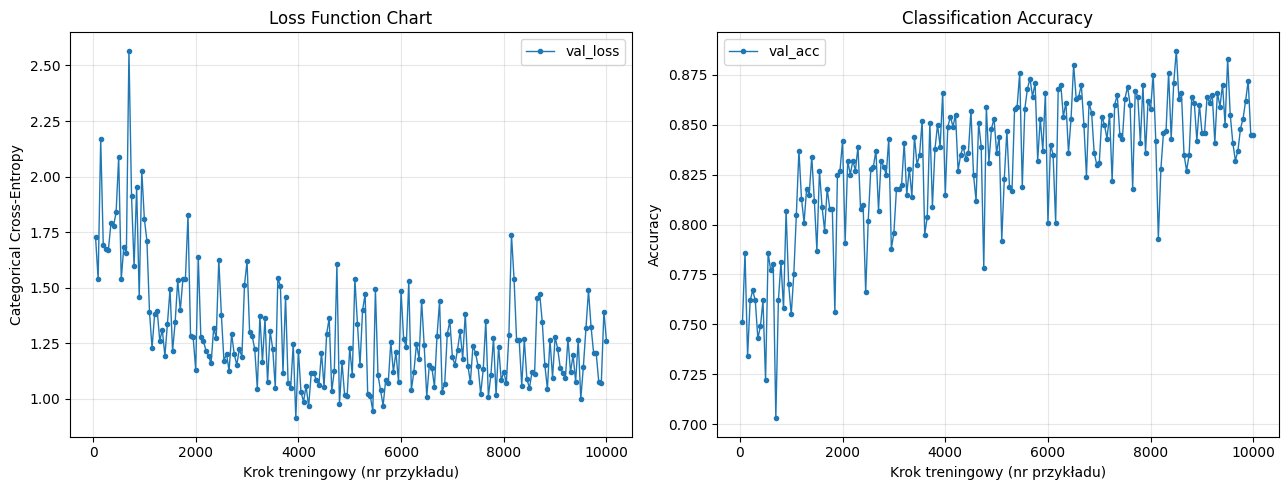

In [109]:
### Wizualizacja przebiegu treningu

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

def plot_chart(ax, label_index, y_label, title):
    val_key = f"val_{label_index}"
    ax.plot(history["step"], history[val_key], marker=".", linewidth=1, label=val_key)
    ax.set_xlabel("Krok treningowy (nr przykładu)")
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)

# Wykres funkcji straty (CCE)
plot_chart(ax=axes[0], label_index="loss", y_label="Categorical Cross-Entropy", title="Loss Function Chart")

# Wykres accuracy
plot_chart(ax=axes[1], label_index="acc", y_label="Accuracy", title="Classification Accuracy")

plt.tight_layout()
plt.show()


FINALNA EWALUACJA NA ZBIORZE TESTOWYM

Test Accuracy: 85.02%

Classification Report:
              precision    recall  f1-score   support

           0     0.9306    0.9714    0.9506       980
           1     0.9594    0.9577    0.9586      1135
           2     0.8928    0.8314    0.8610      1032
           3     0.6136    0.9653    0.7503      1010
           4     0.8741    0.8982    0.8860       982
           5     0.7357    0.7803    0.7573       892
           6     0.9053    0.9280    0.9165       958
           7     0.9489    0.8482    0.8957      1028
           8     0.8584    0.6099    0.7131       974
           9     0.9343    0.6908    0.7943      1009

    accuracy                         0.8502     10000
   macro avg     0.8653    0.8481    0.8483     10000
weighted avg     0.8678    0.8502    0.8506     10000


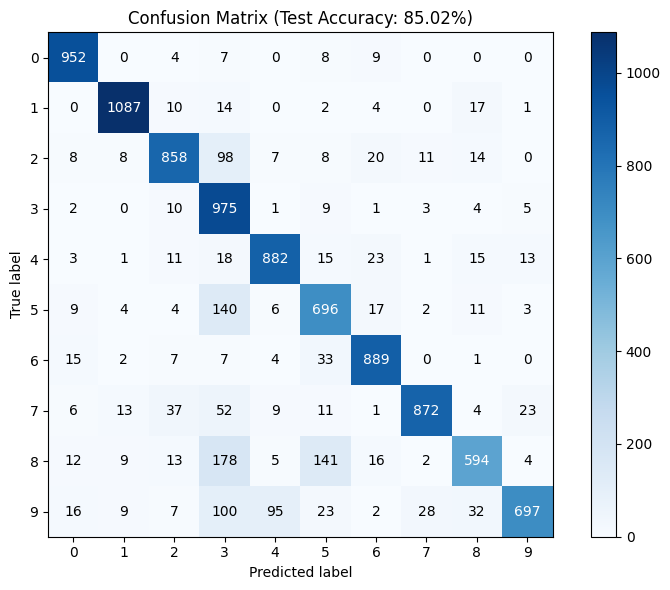

In [110]:
def evaluate(NN, X, y_true):
    y_pred = []
    for k in range(len(X)):
        z = NN.z(X[k])[0]
        a = softmax(z)
        y_pred.append(np.argmax(a))
    return accuracy_score(y_true, y_pred), np.array(y_pred)

def final_evaluation(NN_model : NeuralNetwork):

    # --- PO ZAKOŃCZENIU CAŁEGO TRENINGU: pełne metryki na zbiorze testowym ---
    print("\n" + "=" * 60)
    print("FINALNA EWALUACJA NA ZBIORZE TESTOWYM")
    print("=" * 60)
    
    final_test_acc, y_pred_test = evaluate(NN_model, x_test, y_test)
    print(f"\nTest Accuracy: {final_test_acc:.2%}\n")
    
    print("Classification Report:")
    print(classification_report(y_test, y_pred_test, digits=4))
    
    cm = confusion_matrix(y_test, y_pred_test)
    
    # Wizualizacja confusion matrix
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, cmap='Blues')
    plt.colorbar()
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.title(f'Confusion Matrix (Test Accuracy: {final_test_acc:.2%})')
    plt.xticks(range(10))
    plt.yticks(range(10))
    
    for i in range(10):
        for j in range(10):
            plt.text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black')
    
    plt.tight_layout()
    plt.show()
    
final_evaluation(NN)

100%|██████████| 900/900 [00:00<00:00, 2236.96it/s]


Zakończono trening mini-batch w 0.41s. Liczba pomiarów: 45


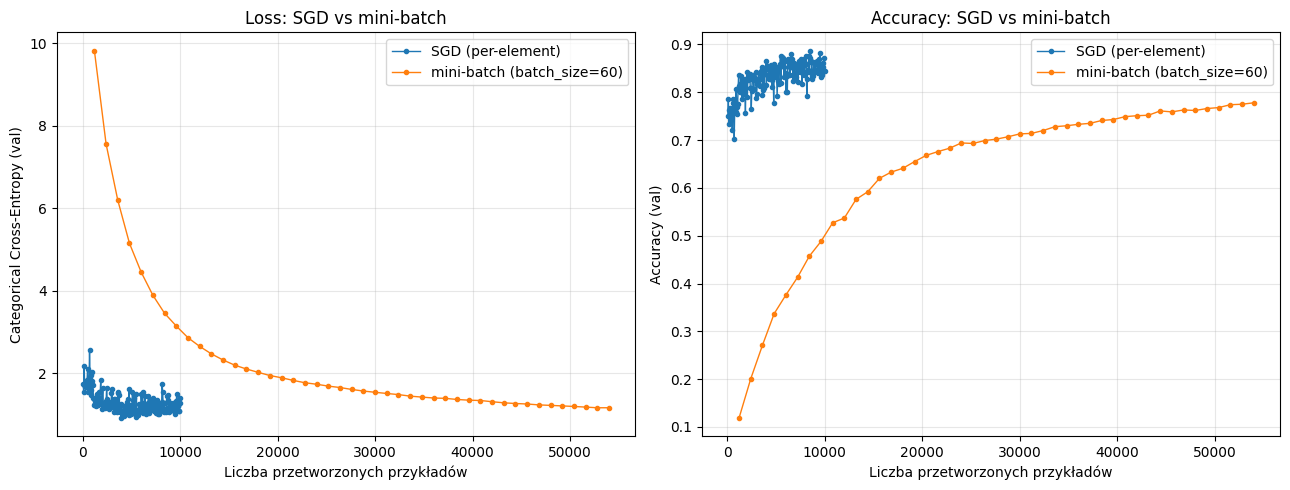

[mini-batch] Test accuracy: 80.55% | Test loss: 0.9490


In [111]:
## Wersja mini-batch SGD (do porównania z czystym SGD powyżej)


def softmax_batch(Z):
    """Softmax liczony wierszami dla macierzy Z o kształcie (batch_size, n_classes)."""
    c = np.max(Z, axis=1, keepdims=True)
    exp_Z = np.exp(Z - c)
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)


def one_hot(labels, num_classes):
    return np.eye(num_classes)[labels]


def train_batch(NN, X_batch, y_batch, learning_rate=0.1):
    """
    Jeden krok mini-batch SGD dla modelu jednowarstwowego (softmax regression).

    X_batch : (batch_size, n_features)
    y_batch : (batch_size,) - etykiety całkowitoliczbowe
    """
    batch_size = X_batch.shape[0]

    # forward (macierzowo, cały batch naraz)
    Z = X_batch @ NN.weights[0].T + NN.biases[0]  # (batch_size, n_classes)
    A = softmax_batch(Z)  # (batch_size, n_classes)

    # gradient: delta = softmax(z) - one_hot(y), uśredniony po batchu
    Y_onehot = one_hot(y_batch, NN.weights[0].shape[0])
    Delta = A - Y_onehot  # (batch_size, n_classes)

    grad_w = (Delta.T @ X_batch) / batch_size  # (n_classes, n_features)
    grad_b = np.mean(Delta, axis=0)  # (n_classes,)

    NN.weights[0] -= learning_rate * grad_w
    NN.biases[0] -= learning_rate * grad_b


def evaluate_with_loss_batch(NN, X, y_true):
    """Zwektoryzowana wersja evaluate_with_loss - do szybkiej ewaluacji większych zbiorów."""
    Z = X @ NN.weights[0].T + NN.biases[0]
    A = softmax_batch(Z)
    y_pred = np.argmax(A, axis=1)
    acc = accuracy_score(y_true, y_pred)
    losses = -np.log(A[np.arange(len(y_true)), y_true] + 1e-12)
    mean_loss = float(np.mean(losses))
    return acc, mean_loss, y_pred


# --- Trening mini-batch ---
import time

batch_size = 60
eval_interval_batches = 20  # co ile batchy robimy pomiar walidacyjny

NN_batch = NeuralNetwork(layer_sizes=[input_size, output_size])

history_batch = {
    "step": [],
    "val_loss": [],
    "val_acc": [],
}

perm = np.random.permutation(len(x_train))
x_train_shuffled = x_train[perm]
y_train_shuffled = y_train[perm]

n_batches = len(x_train_shuffled) // batch_size

start_time = time.time()

for batch_idx in tqdm(range(n_batches)):
    start = batch_idx * batch_size
    end = start + batch_size
    X_batch = x_train_shuffled[start:end]
    y_batch = y_train_shuffled[start:end]

    train_batch(NN_batch, X_batch, y_batch, learning_rate=0.1)

    if (batch_idx + 1) % eval_interval_batches == 0:
        val_acc, val_loss, _ = evaluate_with_loss_batch(NN_batch, x_val_fast, y_val_fast)
        history_batch["step"].append((batch_idx + 1) * batch_size)
        history_batch["val_loss"].append(val_loss)
        history_batch["val_acc"].append(val_acc)

elapsed_batch = time.time() - start_time
print(f"Zakończono trening mini-batch w {elapsed_batch:.2f}s. Liczba pomiarów: {len(history_batch['step'])}")
### Porównanie: SGD (per-element) vs mini-batch SGD

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history["step"], history["val_loss"], marker=".", linewidth=1,
             label="SGD (per-element)")
axes[0].plot(history_batch["step"], history_batch["val_loss"], marker=".", linewidth=1,
             label=f"mini-batch (batch_size={batch_size})")
axes[0].set_xlabel("Liczba przetworzonych przykładów")
axes[0].set_ylabel("Categorical Cross-Entropy (val)")
axes[0].set_title("Loss: SGD vs mini-batch")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history["step"], history["val_acc"], marker=".", linewidth=1,
             label="SGD (per-element)")
axes[1].plot(history_batch["step"], history_batch["val_acc"], marker=".", linewidth=1,
             label=f"mini-batch (batch_size={batch_size})")
axes[1].set_xlabel("Liczba przetworzonych przykładów")
axes[1].set_ylabel("Accuracy (val)")
axes[1].set_title("Accuracy: SGD vs mini-batch")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
### Finalna ewaluacja mini-batch na zbiorze testowym
final_test_acc_batch, final_test_loss_batch, _ = evaluate_with_loss_batch(NN_batch, x_test, y_test)
print(f"[mini-batch] Test accuracy: {final_test_acc_batch:.2%} | Test loss: {final_test_loss_batch:.4f}")

Epoch 1/150: 100%|██████████| 900/900 [00:00<00:00, 1281.18it/s]


Epoch  1/150 | val_loss=1.0490 val_acc=78.57%


Epoch 2/150: 100%|██████████| 900/900 [00:00<00:00, 1146.67it/s]


Epoch  2/150 | val_loss=0.8019 val_acc=83.25%


Epoch 3/150: 100%|██████████| 900/900 [00:00<00:00, 1655.97it/s]


...

Epoch 148/150 | val_loss=0.3186 val_acc=91.55%


Epoch 149/150: 100%|██████████| 900/900 [00:00<00:00, 2159.05it/s]


Epoch 149/150 | val_loss=0.3198 val_acc=91.62%


Epoch 150/150: 100%|██████████| 900/900 [00:00<00:00, 2239.52it/s]


Epoch 150/150 | val_loss=0.3165 val_acc=91.65%

Zakończono trening mini-batch (150 epok) w 72.42s. Liczba pomiarów: 6750


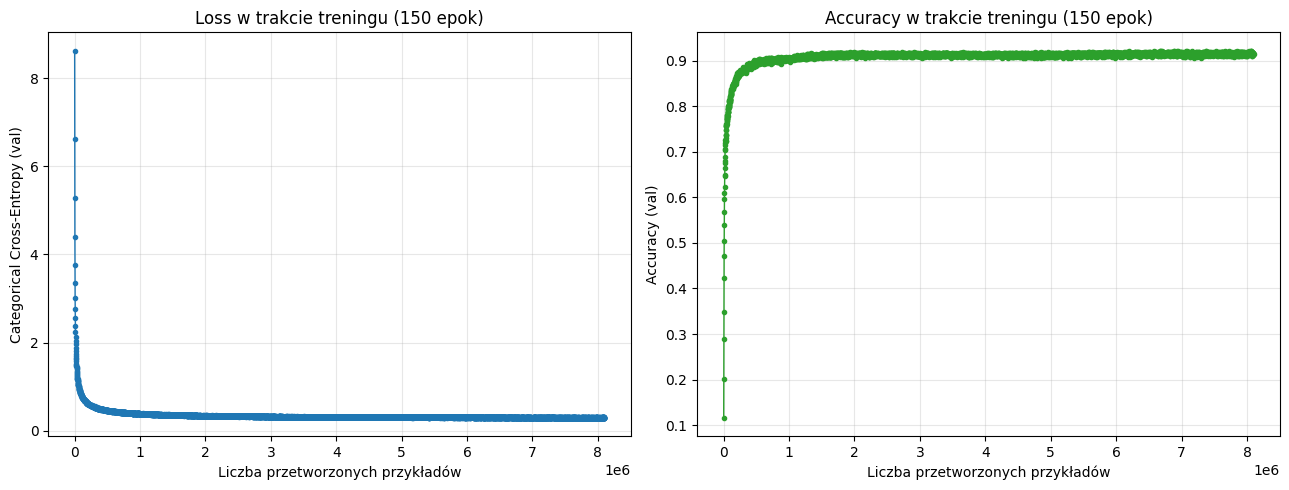

[mini-batch, 150 epok] Test accuracy: 92.29% | Test loss: 0.2935


In [113]:
## Trening mini-batch przez wiele epok
num_epochs_batch = 150

NN_batch = NeuralNetwork(layer_sizes=[input_size, output_size])

history_batch = {
    "step": [],
    "val_loss": [],
    "val_acc": [],
}

global_step = 0  # liczba przetworzonych przykładów, ciągle przez wszystkie epoki

start_time = time.time()

for epoch in range(num_epochs_batch):
    perm = np.random.permutation(len(x_train))
    x_train_shuffled = x_train[perm]
    y_train_shuffled = y_train[perm]

    n_batches = len(x_train_shuffled) // batch_size

    for batch_idx in tqdm(range(n_batches), desc=f"Epoch {epoch + 1}/{num_epochs_batch}"):
        start = batch_idx * batch_size
        end = start + batch_size
        X_batch = x_train_shuffled[start:end]
        y_batch = y_train_shuffled[start:end]

        train_batch(NN_batch, X_batch, y_batch, learning_rate=0.1)
        global_step += batch_size

        if (batch_idx + 1) % eval_interval_batches == 0:
            val_acc, val_loss, _ = evaluate_with_loss_batch(NN_batch, x_val_fast, y_val_fast)
            history_batch["step"].append(global_step)
            history_batch["val_loss"].append(val_loss)
            history_batch["val_acc"].append(val_acc)

    # podsumowanie po każdej epoce (na pełnym x_val, nie tylko x_val_fast)
    epoch_val_acc, epoch_val_loss, _ = evaluate_with_loss_batch(NN_batch, x_val, y_val)
    print(f"Epoch {epoch + 1:>2}/{num_epochs_batch} | "
          f"val_loss={epoch_val_loss:.4f} val_acc={epoch_val_acc:.2%}")

elapsed_batch = time.time() - start_time
print(f"\nZakończono trening mini-batch ({num_epochs_batch} epok) w {elapsed_batch:.2f}s. "
      f"Liczba pomiarów: {len(history_batch['step'])}")
### Wizualizacja przebiegu treningu (wiele epok)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history_batch["step"], history_batch["val_loss"], marker=".", linewidth=1)
axes[0].set_xlabel("Liczba przetworzonych przykładów")
axes[0].set_ylabel("Categorical Cross-Entropy (val)")
axes[0].set_title(f"Loss w trakcie treningu ({num_epochs_batch} epok)")
axes[0].grid(alpha=0.3)

axes[1].plot(history_batch["step"], history_batch["val_acc"], marker=".", linewidth=1, color="tab:green")
axes[1].set_xlabel("Liczba przetworzonych przykładów")
axes[1].set_ylabel("Accuracy (val)")
axes[1].set_title(f"Accuracy w trakcie treningu ({num_epochs_batch} epok)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
### Finalna ewaluacja na zbiorze testowym
final_test_acc_batch, final_test_loss_batch, _ = evaluate_with_loss_batch(NN_batch, x_test, y_test)
print(f"[mini-batch, {num_epochs_batch} epok] Test accuracy: {final_test_acc_batch:.2%} | "
      f"Test loss: {final_test_loss_batch:.4f}")


FINALNA EWALUACJA NA ZBIORZE TESTOWYM

Test Accuracy: 92.29%

Classification Report:
              precision    recall  f1-score   support

           0     0.9509    0.9684    0.9596       980
           1     0.9653    0.9797    0.9725      1135
           2     0.9329    0.8886    0.9102      1032
           3     0.8981    0.9079    0.9030      1010
           4     0.9361    0.9246    0.9303       982
           5     0.8940    0.8700    0.8818       892
           6     0.9304    0.9489    0.9395       958
           7     0.9280    0.9280    0.9280      1028
           8     0.8665    0.8932    0.8797       974
           9     0.9179    0.9088    0.9133      1009

    accuracy                         0.9229     10000
   macro avg     0.9220    0.9218    0.9218     10000
weighted avg     0.9229    0.9229    0.9228     10000


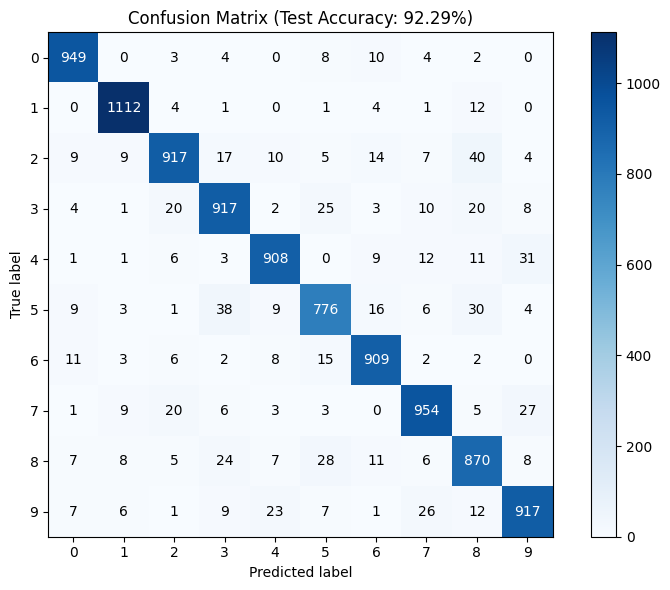

In [114]:
final_evaluation(NN_batch)

In [115]:
from datetime import datetime
import os


def save_model(NN: "NeuralNetwork", filepath: str) -> None:
    """
    Zapisuje parametry modelu (wagi, biasy, layer_sizes) do pliku .npz.

    Parameters
    ----------
    NN : NeuralNetwork
        Wytrenowany model.
    filepath : str
        Ścieżka docelowa, np. "models/model.npz".
    """
    os.makedirs(os.path.dirname(filepath) or ".", exist_ok=True)

    save_dict = {"layer_sizes": np.array(NN.layer_sizes)}
    for i, w in enumerate(NN.weights):
        save_dict[f"weight_{i}"] = w
    for i, b in enumerate(NN.biases):
        save_dict[f"bias_{i}"] = b

    np.savez(filepath, **save_dict)
    print(f"Model zapisany do: {filepath}")


# --- Zapis modelu (per-element SGD) ---
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_path = f"models/mnist_perceptron_sgd_{timestamp}.npz"

save_model(NN, model_path)
# --- Zapis modelu mini-batch (jeśli trenowałeś NN_batch) ---
model_path_batch = f"models/mnist_perceptron_minibatch_{timestamp}.npz"

save_model(NN_batch, model_path_batch)
### Sanity check: czy zapisany plik wczytuje się poprawnie i daje te same wyniki


def load_model(filepath: str) -> "NeuralNetwork":
    """Wczytuje model zapisany funkcją save_model()."""
    data = np.load(filepath)
    layer_sizes = data["layer_sizes"].tolist()

    NN_loaded = NeuralNetwork(layer_sizes=layer_sizes)

    L = len(layer_sizes) - 1
    NN_loaded.weights = [data[f"weight_{i}"] for i in range(L)]
    NN_loaded.biases = [data[f"bias_{i}"] for i in range(L)]

    return NN_loaded


NN_reloaded = load_model(model_path)

acc_original, loss_original, _ = evaluate_with_loss(x_test, y_test)

# tymczasowo podmieniamy globalny NN, bo evaluate_with_loss korzysta z NN jako global
_NN_backup = NN
NN = NN_reloaded
acc_reloaded, loss_reloaded, _ = evaluate_with_loss(x_test, y_test)
NN = _NN_backup

print(f"Accuracy oryginał:      {acc_original:.4%}")
print(f"Accuracy po wczytaniu:  {acc_reloaded:.4%}")
assert np.isclose(acc_original, acc_reloaded), "Wyniki się różnią - coś nie tak z zapisem/wczytaniem!"
print("OK - zapis i wczytanie działają identycznie. Plik jest gotowy do użycia w GUI.")

Model zapisany do: models/mnist_perceptron_sgd_20260716_000733.npz
Model zapisany do: models/mnist_perceptron_minibatch_20260716_000733.npz
Accuracy oryginał:      85.0200%
Accuracy po wczytaniu:  85.0200%
OK - zapis i wczytanie działają identycznie. Plik jest gotowy do użycia w GUI.
